# Naive Bayes across Telco, Bank, and E-Commerce

This notebook applies a common evaluation workflow to three processed datasets in `./data/processed`: Telco, Bank, and E-Commerce.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, TimeSeriesSplit
from sklearn.naive_bayes import BernoulliNB
from sklearn.naive_bayes import CategoricalNB
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error, r2_score, accuracy_score, f1_score, roc_auc_score,
    precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
)
import matplotlib.pyplot as plt

pd.options.display.max_columns = None
pd.options.display.width = 120

TELCO_PATH = "../data/processed/telco_clean.csv"
BANK_PATH = "../data/processed/bank_clean.csv"
ECOM_PATH = "../data/processed/ecom_clean.csv"


def sort_bank_temporally(df):
    """Sort Bank Marketing rows chronologically by month and day_of_week.

    Mirrors src/evaluation.py's sort_dataframe_temporally so the Bank
    train/test split below matches the leak-safe temporal split used for
    Gradient Boosting and the Random Forest deep-dive (paper Section 3.4
    mandates a temporal split for Bank to avoid look-ahead bias).
    """
    month_order = {'jan':1,'feb':2,'mar':3,'apr':4,'may':5,'jun':6,
                   'jul':7,'aug':8,'sep':9,'oct':10,'nov':11,'dec':12}
    day_order = {'mon':1,'tue':2,'wed':3,'thu':4,'fri':5}
    month_num = df['month'].str.lower().map(month_order)
    day_num = df['day_of_week'].str.lower().map(day_order)
    time_idx = month_num * 100 + day_num
    return df.assign(_time_idx=time_idx).sort_values('_time_idx').drop(columns=['_time_idx']).reset_index(drop=True)

## 1. Load datasets

In [2]:
teleco = pd.read_csv(TELCO_PATH)
bank = pd.read_csv(BANK_PATH)
ecom = pd.read_csv(ECOM_PATH)

print("Telco shape:", teleco.shape)
display(teleco.head())

print("Bank shape:", bank.shape)
display(bank.head())

print("E-Commerce shape:", ecom.shape)
display(ecom.head())

Telco shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


Bank shape: (41176, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,6.0,0,failure,1.1,93.994,-36.4,4.857,5191.0,0
1,57,services,married,high.school,no,no,no,telephone,may,mon,149,1,6.0,0,failure,1.1,93.994,-36.4,4.857,5191.0,0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,6.0,0,failure,1.1,93.994,-36.4,4.857,5191.0,0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,6.0,0,failure,1.1,93.994,-36.4,4.857,5191.0,0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,6.0,0,failure,1.1,93.994,-36.4,4.857,5191.0,0


E-Commerce shape: (12205, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,0
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,0
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,0
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,0
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,0


## 2. Preprocess Telco

In [3]:
TELECO_CATEGORICAL = [
    "PaymentMethod", "Contract", "InternetService", "MultipleLines", "gender",
    "Partner", "Dependents", "PhoneService", "PaperlessBilling",
    "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport",
    "StreamingTV", "StreamingMovies"
]

teleco_processed = pd.get_dummies(teleco, columns=TELECO_CATEGORICAL, drop_first=True)
teleco_processed = teleco_processed.drop(columns=["customerID"])

print("Telco processed shape:", teleco_processed.shape)
display(teleco_processed.head())

Telco processed shape: (7043, 31)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Contract_One year,Contract_Two year,InternetService_Fiber optic,InternetService_No,MultipleLines_No phone service,MultipleLines_Yes,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,PaperlessBilling_Yes,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes
0,0,1,29.85,29.85,0,False,True,False,False,False,False,False,True,False,False,True,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False
1,0,34,56.95,1889.50,0,False,False,True,True,False,False,False,False,False,True,False,False,True,False,False,True,False,False,False,True,False,False,False,False,False,False
2,0,2,53.85,108.15,1,False,False,True,False,False,False,False,False,False,True,False,False,True,True,False,True,False,True,False,False,False,False,False,False,False,False
3,0,45,42.30,1840.75,0,False,False,False,True,False,False,False,True,False,True,False,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False
4,0,2,70.70,151.65,1,False,True,False,False,False,True,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False


## 3. Preprocess Bank

In [4]:
bank = sort_bank_temporally(bank)  # chronological order for temporal split

BANK_CATEGORICAL = [
    "job", "marital", "education", "default", "housing", "loan",
    "contact", "month", "day_of_week", "poutcome"
]

bank_processed = pd.get_dummies(bank, columns=BANK_CATEGORICAL, drop_first=True)
print("Bank processed shape:", bank_processed.shape)
display(bank_processed.head())

Bank processed shape: (41176, 47)


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,marital_married,marital_single,education_basic.6y,education_basic.9y,education_high.school,education_illiterate,education_professional.course,education_university.degree,default_yes,housing_yes,loan_yes,contact_telephone,month_aug,month_dec,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_success
0,75,233,1,6.0,0,-1.8,92.843,-50.0,1.560,5099.1,0,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False
1,53,247,5,6.0,2,-1.8,93.369,-34.8,0.646,5008.7,0,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,True,False,False,True,False,True,False,False,False,False,True,False,False,False,False,True,False,False,False,False
2,48,151,1,6.0,1,-1.8,93.369,-34.8,0.646,5008.7,0,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False
3,62,192,1,6.0,1,-1.8,93.369,-34.8,0.646,5008.7,1,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,True
4,29,257,1,6.0,0,-1.8,93.369,-34.8,0.646,5008.7,1,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,True,True,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False


## 4. Preprocess E-Commerce

In [5]:
ECOM_CATEGORICAL = ["Month", "VisitorType"]
ecom_processed = pd.get_dummies(ecom, columns=ECOM_CATEGORICAL, drop_first=True)
print("E-Commerce processed shape:", ecom_processed.shape)
display(ecom_processed.head())

E-Commerce processed shape: (12205, 27)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType,Weekend,Revenue,Month_Dec,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,1,1,1,1,False,0,False,True,False,False,False,False,False,False,False,False,True
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,2,2,1,2,False,0,False,True,False,False,False,False,False,False,False,False,True
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,4,1,9,3,False,0,False,True,False,False,False,False,False,False,False,False,True
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,3,2,2,4,False,0,False,True,False,False,False,False,False,False,False,False,True
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,3,3,1,4,True,0,False,True,False,False,False,False,False,False,False,False,True


## 5. Evaluation helper

In [6]:
def evaluate_model(model, X_train, y_train, X_test, y_test, cv=5, show_cm=False, title="", display_labels=None, temporal=False):
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    y_test_score = model.predict_proba(X_test)[:, 1]

    # Bank uses TimeSeriesSplit (not shuffled k-fold) for CV, consistent with
    # the temporal train/test split and with src/evaluation.py's split_mode='temporal'.
    cv_splitter = TimeSeriesSplit(n_splits=cv) if temporal else cv

    train_accuracy = accuracy_score(y_train, y_train_pred)
    valid_accuracy = accuracy_score(y_test, y_test_pred)
    mean_cv_score = cross_val_score(model, X_train, y_train, cv=cv_splitter, scoring='accuracy').mean()
    cv_auc_scores = cross_val_score(model, X_train, y_train, cv=cv_splitter, scoring='roc_auc')
    roc_auc = roc_auc_score(y_test, y_test_score)
    f1 = f1_score(y_test, y_test_pred)
    precision = precision_score(y_test, y_test_pred)
    recall = recall_score(y_test, y_test_pred)

    print(f"Test set ROC-AUC: {roc_auc:.4f}")
    print(f"F1:               {f1:.4f}\n")
    print(classification_report(y_test, y_test_pred, target_names=display_labels))

    if show_cm:
        cm = confusion_matrix(y_test, y_test_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
        disp.plot(cmap="Blues")
        disp.ax_.set_xlabel("Vorhergesagte Klasse")
        disp.ax_.set_ylabel("Tatsächliche Klasse")
        plt.title(title)
        plt.tight_layout()
        plt.show()

    return train_accuracy, valid_accuracy, mean_cv_score, cv_auc_scores, roc_auc, f1, precision, recall


def format_scores(features, selected_features, train_accuracy, valid_accuracy, mean_cv_score, cv_auc_scores, roc_auc, f1, precision, recall):
    result = pd.DataFrame([{
        "Features": features,
        "Selected Features": selected_features,
        "Train Accuracy": f"{train_accuracy:.4f}",
        "Valid Accuracy": f"{valid_accuracy:.4f}",
        "Mean CV Score": f"{mean_cv_score:.4f}",
        "CV-AUC": f"{cv_auc_scores.mean():.4f} ± {cv_auc_scores.std():.4f}",
        "ROC AUC": f"{roc_auc:.4f}",
        "F1": f"{f1:.4f}",
        "Precision": f"{precision:.4f}",
        "Recall": f"{recall:.4f}",
    }])
    return result


In [7]:
def run_dataset(X, y, scale=False, display_labels=None, title="", temporal=False):
    if temporal:
        # Chronological 80/20 split (no shuffling) for Bank Marketing.
        split_idx = int(len(X) * 0.8)
        X_train, X_test = X[:split_idx], X[split_idx:]
        y_train, y_test = y[:split_idx], y[split_idx:]
    else:
        X_train, X_test, y_train, y_test = train_test_split(
            X,
            y,
            test_size=0.20,
            random_state=42,
            stratify=y
        )

    # ausklammern das Naive Bayes nicht von Skalierung profitiert
    '''
        if scale:
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test) '''
    # model = CategoricalNB() # CategoricalNB ist für kategorische Daten, aber da wir bereits One-Hot-Encoding angewendet haben, ist BernoulliNB besser geeignet
    
    model = BernoulliNB()
    train_accuracy, valid_accuracy, mean_cv_score, cv_auc_scores, roc_auc, f1, precision, recall = evaluate_model(model, X_train, y_train, X_test, y_test, show_cm=True, title=title, display_labels=display_labels, temporal=temporal)
    features = X.shape[1]
    selected_features = features
    return format_scores(features, selected_features, train_accuracy, valid_accuracy, mean_cv_score, cv_auc_scores, roc_auc, f1, precision, recall)


def run_dataset_tuned(X, y, display_labels=None, title="", temporal=False):
    if temporal:
        split_idx = int(len(X) * 0.8)
        X_train, X_test = X[:split_idx], X[split_idx:]
        y_train, y_test = y[:split_idx], y[split_idx:]
    else:
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.20, random_state=42, stratify=y
        )

    # Alpha-Tuning via GridSearchCV
    params = {'alpha': [0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0]}
    tuning_cv = TimeSeriesSplit(n_splits=5) if temporal else 5
    grid = GridSearchCV(BernoulliNB(), params, cv=tuning_cv, scoring='f1')
    grid.fit(X_train, y_train)
    
    best_model = grid.best_estimator_
    print(f"Bestes Alpha: {grid.best_params_['alpha']}")

    train_accuracy, valid_accuracy, mean_cv_score, cv_auc_scores, roc_auc, f1, precision, recall = evaluate_model(
        best_model, X_train, y_train, X_test, y_test,
        show_cm=True,
        display_labels=display_labels,
        title=title,
        temporal=temporal
    )
    return format_scores(X.shape[1], X.shape[1], train_accuracy, valid_accuracy, mean_cv_score, cv_auc_scores, roc_auc, f1, precision, recall)


## 6. Telco results

Telco - untuned features


Test set ROC-AUC: 0.7924
F1:               0.5842

              precision    recall  f1-score   support

  Kein Churn       0.90      0.68      0.77      1035
       Churn       0.47      0.78      0.58       374

    accuracy                           0.70      1409
   macro avg       0.68      0.73      0.68      1409
weighted avg       0.78      0.70      0.72      1409



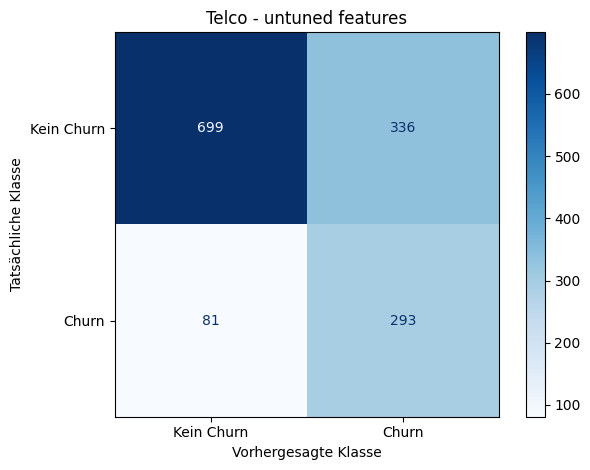

,Features,Selected Features,Train Accuracy,Valid Accuracy,Mean CV Score,CV-AUC,ROC AUC,F1,Precision,Recall
0,30,30,0.7167,0.7040,0.7151,0.8098 ± 0.0232,0.7924,0.5842,0.4658,0.7834


Telco - tuned features


Bestes Alpha: 0.001


Test set ROC-AUC: 0.7925
F1:               0.5848

              precision    recall  f1-score   support

  Kein Churn       0.90      0.68      0.77      1035
       Churn       0.47      0.78      0.58       374

    accuracy                           0.70      1409
   macro avg       0.68      0.73      0.68      1409
weighted avg       0.78      0.70      0.72      1409



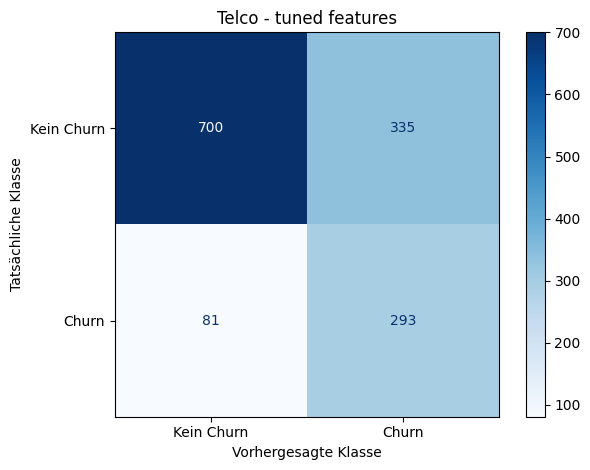

,Features,Selected Features,Train Accuracy,Valid Accuracy,Mean CV Score,CV-AUC,ROC AUC,F1,Precision,Recall
0,30,30,0.7169,0.7048,0.7158,0.8099 ± 0.0231,0.7925,0.5848,0.4666,0.7834


In [8]:
X_telco = teleco_processed.drop(columns=["Churn"]).to_numpy()
y_telco = teleco_processed["Churn"].to_numpy()

print("Telco - untuned features")
display(run_dataset(X_telco, y_telco, scale=False, display_labels=["Kein Churn", "Churn"], title="Telco - untuned features"))

print("Telco - tuned features")
display(run_dataset_tuned(X_telco, y_telco, display_labels=["Kein Churn", "Churn"], title="Telco - tuned features"))

## 7. Bank results

Bank - untuned features


Test set ROC-AUC: 0.7114
F1:               0.3318

                 precision    recall  f1-score   support

No Subscription       0.91      0.39      0.54      6861
   Subscription       0.21      0.81      0.33      1375

       accuracy                           0.46      8236
      macro avg       0.56      0.60      0.44      8236
   weighted avg       0.79      0.46      0.51      8236



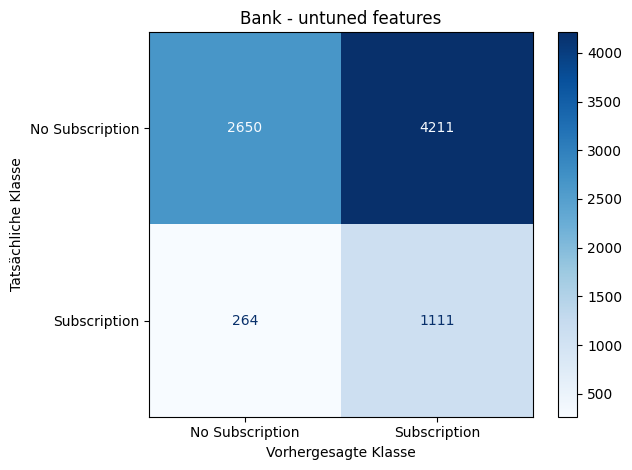

,Features,Selected Features,Train Accuracy,Valid Accuracy,Mean CV Score,CV-AUC,ROC AUC,F1,Precision,Recall
0,46,46,0.8901,0.4567,0.8387,0.6978 ± 0.0504,0.7114,0.3318,0.2088,0.8080


Bank - tuned features


Bestes Alpha: 2.0


Test set ROC-AUC: 0.7114
F1:               0.3316

                 precision    recall  f1-score   support

No Subscription       0.91      0.39      0.54      6861
   Subscription       0.21      0.81      0.33      1375

       accuracy                           0.46      8236
      macro avg       0.56      0.60      0.44      8236
   weighted avg       0.79      0.46      0.51      8236



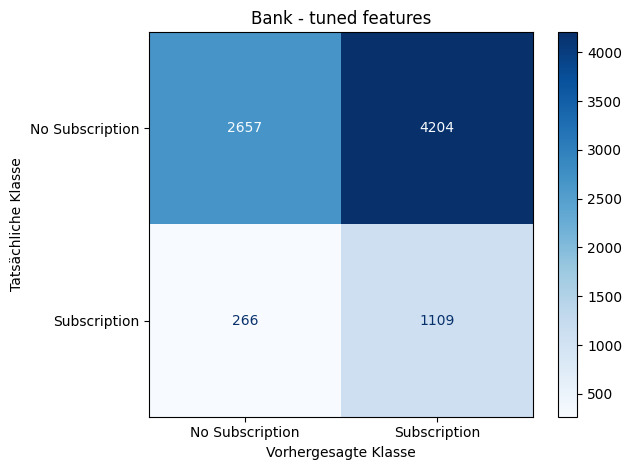

,Features,Selected Features,Train Accuracy,Valid Accuracy,Mean CV Score,CV-AUC,ROC AUC,F1,Precision,Recall
0,46,46,0.8901,0.4573,0.8398,0.6977 ± 0.0504,0.7114,0.3316,0.2087,0.8065


In [9]:
X_bank = bank_processed.drop(columns=["y"]).to_numpy()
y_bank = bank_processed["y"].to_numpy()

print("Bank - untuned features")
display(run_dataset(X_bank, y_bank, scale=False, display_labels=["No Subscription", "Subscription"], title="Bank - untuned features", temporal=True))

print("Bank - tuned features")
display(run_dataset_tuned(X_bank, y_bank, display_labels=["No Subscription", "Subscription"], title="Bank - tuned features", temporal=True))

## 8. E-Commerce results

E-Commerce - untuned features


Test set ROC-AUC: 0.8812
F1:               0.5757

              precision    recall  f1-score   support

 No Purchase       0.93      0.91      0.92      2059
    Purchase       0.55      0.61      0.58       382

    accuracy                           0.86      2441
   macro avg       0.74      0.76      0.75      2441
weighted avg       0.87      0.86      0.86      2441



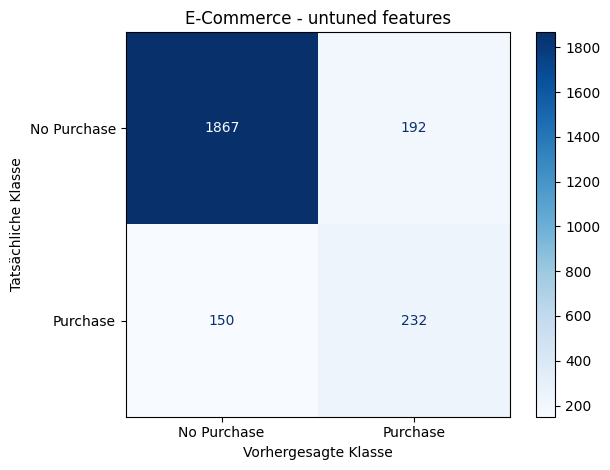

,Features,Selected Features,Train Accuracy,Valid Accuracy,Mean CV Score,CV-AUC,ROC AUC,F1,Precision,Recall
0,26,26,0.8588,0.8599,0.8576,0.8765 ± 0.0047,0.8812,0.5757,0.5472,0.6073


E-Commerce - tuned features


Bestes Alpha: 0.5


Test set ROC-AUC: 0.8811
F1:               0.5757

              precision    recall  f1-score   support

 No Purchase       0.93      0.91      0.92      2059
    Purchase       0.55      0.61      0.58       382

    accuracy                           0.86      2441
   macro avg       0.74      0.76      0.75      2441
weighted avg       0.87      0.86      0.86      2441



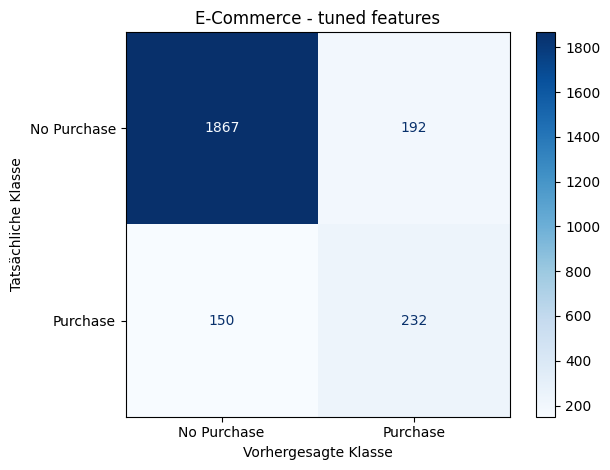

,Features,Selected Features,Train Accuracy,Valid Accuracy,Mean CV Score,CV-AUC,ROC AUC,F1,Precision,Recall
0,26,26,0.8587,0.8599,0.8581,0.8763 ± 0.0046,0.8811,0.5757,0.5472,0.6073


In [10]:
X_ecom = ecom_processed.drop(columns=["Revenue"]).to_numpy()
y_ecom = ecom_processed["Revenue"].to_numpy()

print("E-Commerce - untuned features")
display(run_dataset(X_ecom, y_ecom, scale=False, display_labels=["No Purchase", "Purchase"], title="E-Commerce - untuned features"))

print("E-Commerce - tuned features")
display(run_dataset_tuned(X_ecom, y_ecom, display_labels=["No Purchase", "Purchase"], title="E-Commerce - tuned features"))

## 9. Summary

Test set ROC-AUC: 0.7924
F1:               0.5842

              precision    recall  f1-score   support

           0       0.90      0.68      0.77      1035
           1       0.47      0.78      0.58       374

    accuracy                           0.70      1409
   macro avg       0.68      0.73      0.68      1409
weighted avg       0.78      0.70      0.72      1409



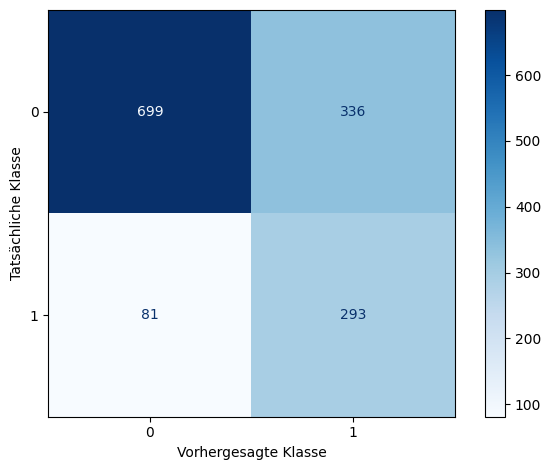

Test set ROC-AUC: 0.8812
F1:               0.5757

              precision    recall  f1-score   support

           0       0.93      0.91      0.92      2059
           1       0.55      0.61      0.58       382

    accuracy                           0.86      2441
   macro avg       0.74      0.76      0.75      2441
weighted avg       0.87      0.86      0.86      2441



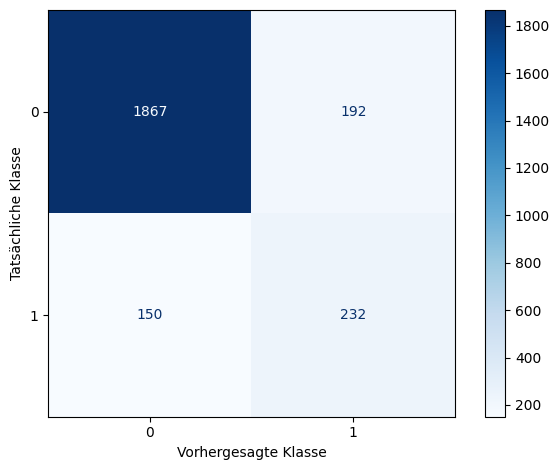

Test set ROC-AUC: 0.7114
F1:               0.3318

              precision    recall  f1-score   support

           0       0.91      0.39      0.54      6861
           1       0.21      0.81      0.33      1375

    accuracy                           0.46      8236
   macro avg       0.56      0.60      0.44      8236
weighted avg       0.79      0.46      0.51      8236



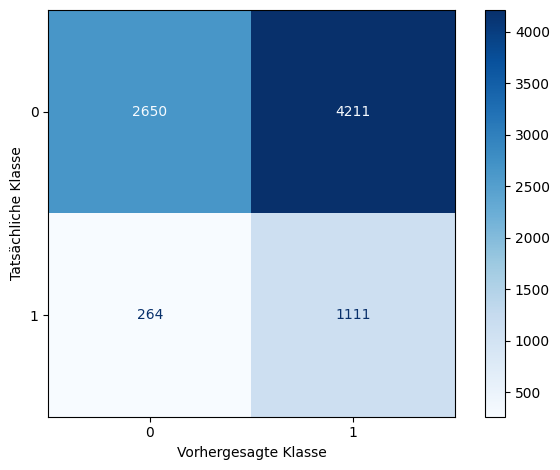

Model Performance Summary (Naive Bayes - BernoulliNB):


,CV-AUC,Test-AUC,F1,Prec.,Recall
Dataset,,,,,
Telco Churn,0.8098 ± 0.0232,0.7924,0.5842,0.4658,0.7834
Online Shoppers,0.8765 ± 0.0047,0.8812,0.5757,0.5472,0.6073
Bank Marketing,0.6978 ± 0.0504,0.7114,0.3318,0.2088,0.8080


In [11]:
datasets = [
    ("Telco Churn",     X_telco, y_telco, False),
    ("Online Shoppers", X_ecom,  y_ecom,  False),
    ("Bank Marketing",  X_bank,  y_bank,  True),
]

summary_rows = []
for name, X, y, temporal in datasets:
    row = run_dataset(X, y, scale=False, temporal=temporal)
    summary_rows.append({
        "Dataset":  name,
        "CV-AUC":   row["CV-AUC"].iloc[0],
        "Test-AUC": row["ROC AUC"].iloc[0],
        "F1":       row["F1"].iloc[0],
        "Prec.":    row["Precision"].iloc[0],
        "Recall":   row["Recall"].iloc[0],
    })

# Naive Bayes uses BernoulliNB with default settings, no hyperparameter search
summary_df = pd.DataFrame(summary_rows).set_index("Dataset")
print("Model Performance Summary (Naive Bayes - BernoulliNB):")
display(summary_df)